In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


In [3]:
df=pd.read_csv("city_day.csv")

In [4]:
df.head()

,City,Date,PM2.5,PM10,NO,NO2,NOx,NH3,CO,SO2,O3,Benzene,Toluene,Xylene,AQI,AQI_Bucket
0,Lahore,1/1/2015,NaN,NaN,0.92,18.22,17.15,NaN,0.92,27.64,133.36,0.00,0.02,0.00,NaN,NaN
1,Lahore,1/2/2015,NaN,NaN,0.97,15.69,16.46,NaN,0.97,24.55,34.06,3.68,5.50,3.77,NaN,NaN
2,Lahore,1/3/2015,NaN,NaN,17.40,19.30,29.70,NaN,17.40,29.07,30.70,6.80,16.40,2.25,NaN,NaN
3,Lahore,1/4/2015,NaN,NaN,1.70,18.48,17.97,NaN,1.70,18.59,36.08,4.43,10.14,1.00,NaN,NaN
4,Lahore,1/5/2015,NaN,NaN,22.10,21.42,37.76,NaN,22.10,39.33,39.31,7.01,18.89,2.78,NaN,NaN


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 29531 entries, 0 to 29530
Data columns (total 16 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   City        29531 non-null  object 
 1   Date        29531 non-null  object 
 2   PM2.5       24933 non-null  float64
 3   PM10        18391 non-null  float64
 4   NO          25949 non-null  float64
 5   NO2         25946 non-null  float64
 6   NOx         25346 non-null  float64
 7   NH3         19203 non-null  float64
 8   CO          27472 non-null  float64
 9   SO2         25677 non-null  float64
 10  O3          25509 non-null  float64
 11  Benzene     23908 non-null  float64
 12  Toluene     21490 non-null  float64
 13  Xylene      11422 non-null  float64
 14  AQI         24850 non-null  float64
 15  AQI_Bucket  24850 non-null  object 
dtypes: float64(13), object(3)
memory usage: 3.6+ MB


In [6]:
df.isna().sum()

City              0
Date              0
PM2.5          4598
PM10          11140
NO             3582
NO2            3585
NOx            4185
NH3           10328
CO             2059
SO2            3854
O3             4022
Benzene        5623
Toluene        8041
Xylene        18109
AQI            4681
AQI_Bucket     4681
dtype: int64

In [7]:
df["AQI"].value_counts()

AQI
102.0     223
100.0     222
70.0      208
106.0     208
78.0      198
         ... 
1044.0      1
679.0       1
1222.0      1
1459.0      1
13.0        1
Name: count, Length: 829, dtype: int64

# EDA Handling Missing Values

In [8]:
pmean=df["PM2.5"].mean()
df["PM2.5"].fillna(pmean,inplace=True)

In [9]:
pmmean=df["PM10"].mean()
df["PM10"].fillna(pmmean,inplace=True)

In [10]:
nmean=df["NO"].mean()
df["NO"].fillna(nmean,inplace=True)

In [11]:
nomean=df["NO2"].mean()
df["NO2"].fillna(nomean,inplace=True)

In [12]:
noxmean=df["NOx"].mean()
df["NOx"].fillna(noxmean,inplace=True)

In [13]:
nhmean=df["NH3"].mean()
df["NH3"].fillna(nhmean,inplace=True)

In [14]:
cmean=df["CO"].mean()
df["CO"].fillna(cmean,inplace=True)

In [15]:
smean=df["SO2"].mean()
df["SO2"].fillna(smean,inplace=True)

In [16]:
omean=df["O3"].mean()
df["O3"].fillna(omean, inplace=True)

In [17]:
bmean=df["Benzene"].mean()
df["Benzene"].fillna(bmean,inplace=True)

In [18]:
tmean=df["Toluene"].mean()
df["Toluene"].fillna(tmean,inplace=True)

In [19]:
xmean=df["Xylene"].mean()
df["Xylene"].fillna(xmean,inplace=True)

In [20]:
amean=df["AQI"].mean()
df["AQI"].fillna(amean,inplace=True)

In [21]:
df=df.drop('AQI_Bucket',axis=1)

In [22]:
df.isna().sum()

City       0
Date       0
PM2.5      0
PM10       0
NO         0
NO2        0
NOx        0
NH3        0
CO         0
SO2        0
O3         0
Benzene    0
Toluene    0
Xylene     0
AQI        0
dtype: int64

# Dividing the Data into X and Y

In [23]:
x=df.iloc[:,2:13].values
y=df.iloc[:,-1].values

In [24]:
x

array([[6.74505779e+01, 1.18127103e+02, 9.20000000e-01, ...,
        1.33360000e+02, 0.00000000e+00, 2.00000000e-02],
       [6.74505779e+01, 1.18127103e+02, 9.70000000e-01, ...,
        3.40600000e+01, 3.68000000e+00, 5.50000000e+00],
       [6.74505779e+01, 1.18127103e+02, 1.74000000e+01, ...,
        3.07000000e+01, 6.80000000e+00, 1.64000000e+01],
       ...,
       [2.29100000e+01, 6.57300000e+01, 3.45000000e+00, ...,
        3.09600000e+01, 1.00000000e-02, 1.00000000e-02],
       [1.66400000e+01, 4.99700000e+01, 4.05000000e+00, ...,
        2.83000000e+01, 0.00000000e+00, 0.00000000e+00],
       [1.50000000e+01, 6.60000000e+01, 4.00000000e-01, ...,
        1.70500000e+01, 3.28084030e+00, 8.70097208e+00]])

In [25]:
y

array([166.46358149, 166.46358149, 166.46358149, ...,  68.        ,
        54.        ,  50.        ])

In [26]:
from sklearn.model_selection import train_test_split

In [45]:
xtrain,xtest,ytrain,ytest= train_test_split(x,y,test_size=0.4,random_state=0)

In [46]:
from sklearn.linear_model import LinearRegression

In [47]:
linreg=LinearRegression()

In [48]:
linreg.fit(xtrain,ytrain)
ypred=linreg.predict(xtest)

# Model Evaluation

In [49]:
x=df.iloc[:,2:13]
y=df.iloc[:,-1]

In [50]:
linreg.intercept_

15.910905630310225

In [51]:
linreg.coef_

array([ 0.97166942,  0.27059773, -0.04251939,  0.39521378,  0.1354899 ,
       -0.04517784, 10.02152201,  0.62990974,  0.18376814, -0.27026871,
        0.20484948])

In [52]:
coef_df=pd.DataFrame(linreg.coef_,x.columns,columns=["Coefficient"])
coef_df

,Coefficient
PM2.5,0.971669
PM10,0.270598
NO,-0.042519
NO2,0.395214
NOx,0.135490
NH3,-0.045178
CO,10.021522
SO2,0.629910
O3,0.183768
Benzene,-0.270269


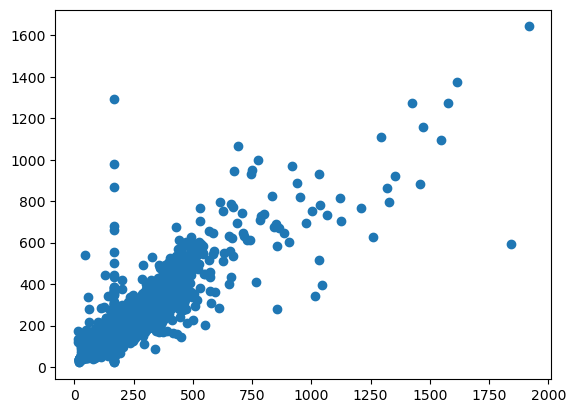

In [53]:
plt.scatter(ytest,ypred)

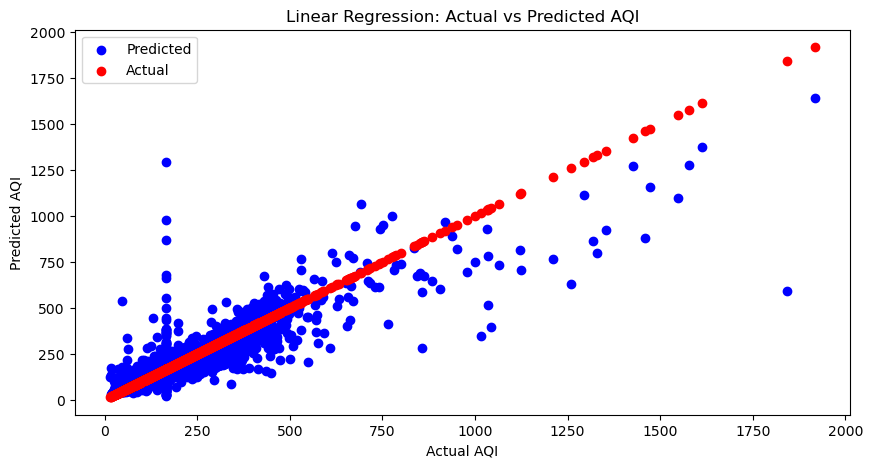

C:\Users\Haroon1\AppData\Local\Temp\ipykernel_10084\2723835346.py:11: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot((ytest-ypred),bins=50)
C:\Users\Haroon1\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


<Axes: xlabel='AQI', ylabel='Density'>

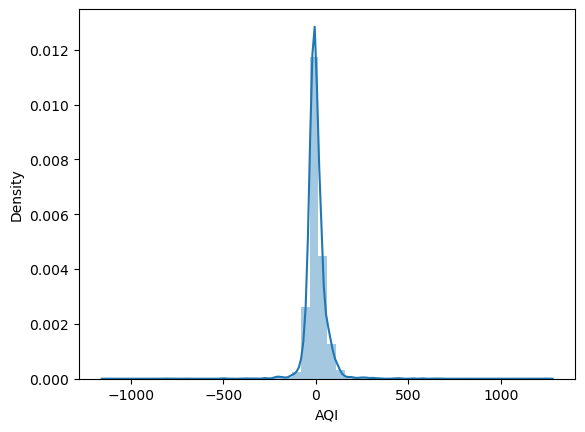

In [54]:
plt.figure(figsize=(10, 5))
plt.scatter(ytest, ypred, color='blue', label='Predicted')
plt.scatter(ytest, ytest, color='red', label='Actual')
plt.xlabel('Actual AQI')
plt.ylabel('Predicted AQI')
plt.title('Linear Regression: Actual vs Predicted AQI')
plt.legend()
plt.show()


sns.distplot((ytest-ypred),bins=50)

In [55]:
from sklearn.metrics import mean_absolute_error as mae, mean_squared_error as mse,r2_score

In [56]:
print(f"MSE:{mse(ytest,ypred)}")

MSE:3646.847281871661


In [57]:
print(f"R-squared:{r2_score(ytest,ypred)}")

R-squared:0.7882479553866867
